# PCA on the Iris dataset

The Iris dataset is a classical dataset to learn to use Machine Learning methods. We're going to use it here to see how to use PCA and some traps to avoid.

## Getting data

In [1]:
import math

import matplotlib.pyplot as plt
import numpy
import plotly.express as px
import scipy.stats
import sklearn.decomposition
import sklearn.preprocessing

df = px.data.iris()

print("5 first lines")
print(df.head(5))
print()
print("Description of the numerical features")
print(df.describe())

5 first lines
   sepal_length  sepal_width  petal_length  petal_width species  species_id
0           5.1          3.5           1.4          0.2  setosa           1
1           4.9          3.0           1.4          0.2  setosa           1
2           4.7          3.2           1.3          0.2  setosa           1
3           4.6          3.1           1.5          0.2  setosa           1
4           5.0          3.6           1.4          0.2  setosa           1

Description of the numerical features
       sepal_length  sepal_width  petal_length  petal_width  species_id
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.054000      3.758667     1.198667    2.000000
std        0.828066     0.433594      1.764420     0.763161    0.819232
min        4.300000     2.000000      1.000000     0.100000    1.000000
25%        5.100000     2.800000      1.600000     0.300000    1.000000
50%        5.800000     3.000000      4.350000     1.300000

## Preparing features and targets

The targets will be used here for visualization only, not for training.

In [2]:
X = df.drop(columns=["species", "species_id"]).values
y = df["species_id"].values

## Visualizing the data

In [3]:
styling = dict(template="seaborn", width=800, height=600)


def show(fig):
  fig.update_traces(
    marker=dict(line=dict(width=1, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
  )
  fig.show()


fig = px.scatter_3d(
  df,
  x="sepal_length",
  y="sepal_width",
  z="petal_length",
  color="species",
  hover_data=["petal_width"],  # Overlay petal_width
  **styling,
)
show(fig)

## Computing PCA

In [4]:
pca = sklearn.decomposition.PCA(n_components=3)
pca.fit(X)

X_pca = pca.transform(X)

print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulated explained variance:", numpy.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.92461621 0.05301557 0.01718514]
Cumulated explained variance: [0.92461621 0.97763178 0.99481691]


## Visualizing the learned linear projections

In [5]:
fig = px.scatter_3d(X_pca, x=0, y=1, z=2, color=df["species"], **styling)
show(fig)

## Dimensionality reduction

In [6]:
fig = px.scatter(X_pca, x=0, y=1, color=df["species"], **styling)
show(fig)

## Principal components exploration

In [7]:
print("Components", pca.components_)

for k, v in enumerate(numpy.argsort(numpy.abs(pca.components_))):
  print()
  print(f"Features coefficients for component {k}")
  for i in v[::-1]:
    print(f"  {df.columns[i]}: {pca.components_[k][i]}")

Components [[ 0.36158968 -0.08226889  0.85657211  0.35884393]
 [ 0.65653988  0.72971237 -0.1757674  -0.07470647]
 [-0.58099728  0.59641809  0.07252408  0.54906091]]

Features coefficients for component 0
  petal_length: 0.8565721052905283
  sepal_length: 0.36158967738144937
  petal_width: 0.358843926248215
  sepal_width: -0.08226888989221426

Features coefficients for component 1
  sepal_width: 0.7297123713265224
  sepal_length: 0.6565398832858071
  petal_length: -0.17576740342864328
  petal_width: -0.07470647013502835

Features coefficients for component 2
  sepal_width: 0.5964180879380312
  sepal_length: -0.5809972798275927
  petal_width: 0.5490609107267171
  petal_length: 0.07252407548689854


# Features units and variance

Those results should be interpreted with caution: we could be lead to believe that 92% of the variance is explained thanks to the first component. However, we did not standardize the data, so a feature with bigger values will likely dominate variance.

There is a simple solution: standardizing.

In [8]:
X_scaler = sklearn.preprocessing.StandardScaler()
X_scaler.fit(X)
X_scaled = X_scaler.transform(X)
# X_scaled = X_scaler.fit_transform(X)
print(X_scaled.shape)

(150, 4)


In [9]:
pca = sklearn.decomposition.PCA(n_components=3)
pca.fit(X_scaled)
X_scaled_pca = pca.transform(X_scaled)

print(
  "Explained variance for each component:",
  ", ".join(f"{v:.2f}" for v in pca.explained_variance_ratio_),
)
print(
  "Cumulated explained variance:",
  ", ".join(f"{v:.2f}" for v in numpy.cumsum(pca.explained_variance_ratio_)),
)

Explained variance for each component: 0.73, 0.23, 0.04
Cumulated explained variance: 0.73, 0.96, 0.99


In [10]:
fig = px.scatter_3d(X_scaled_pca, x=0, y=1, z=2, color=df["species"], **styling)
show(fig)

In [11]:
print("Components", pca.components_)

for k, v in enumerate(numpy.argsort(numpy.abs(pca.components_))):
  print()
  print(f"Features coefficients for component {k}")
  for i in v[::-1]:
    print(f"  {df.columns[i]}: {pca.components_[k][i]}")

Components [[ 0.52237162 -0.26335492  0.58125401  0.56561105]
 [ 0.37231836  0.92555649  0.02109478  0.06541577]
 [ 0.72101681 -0.24203288 -0.14089226 -0.6338014 ]]

Features coefficients for component 0
  petal_length: 0.5812540055976482
  petal_width: 0.5656110498826494
  sepal_length: 0.5223716204076599
  sepal_width: -0.2633549153139405

Features coefficients for component 1
  sepal_width: 0.9255564941472945
  sepal_length: 0.37231836334996954
  petal_width: 0.06541576907892821
  petal_length: 0.021094776841246277

Features coefficients for component 2
  sepal_length: 0.7210168090620424
  petal_width: -0.6338014033558239
  sepal_width: -0.24203287721394112
  petal_length: -0.14089225848754064


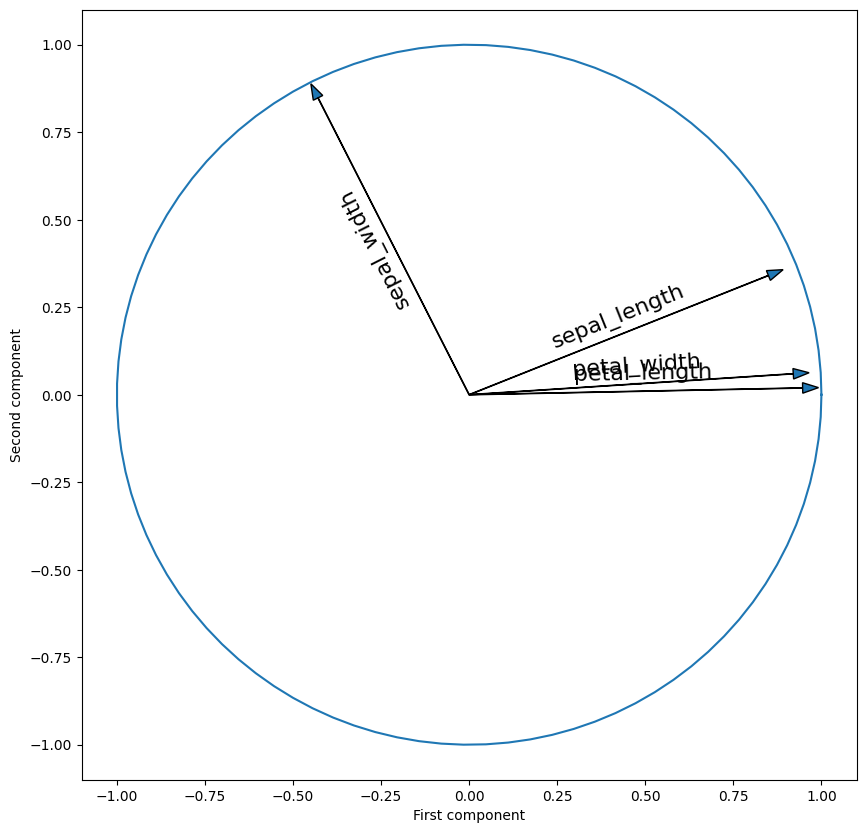

In [12]:
t = numpy.linspace(0, numpy.pi * 2, 100)

plt.figure(figsize=(10, 10))
plt.xlim((-1.1, 1.1))
plt.ylim((-1.1, 1.1))
for feature in range(X_scaled.shape[1]):
  corr_0 = scipy.stats.pearsonr(X_scaled[:, feature], X_scaled_pca[:, 0])[0]
  corr_1 = scipy.stats.pearsonr(X_scaled[:, feature], X_scaled_pca[:, 1])[0]
  r = math.atan2(corr_1, corr_0)
  plt.arrow(0, 0, corr_0, corr_1, length_includes_head=True, head_width=0.03)
  plt.text(
    corr_0 / 2 + (math.cos(r + 0.1) - math.cos(r)) / 2,
    corr_1 / 2 + (math.sin(r + 0.1) - math.sin(r)) / 2,
    df.columns[feature],
    rotation=numpy.degrees(r),
    size=16,
    ha="center",
    va="center",
  )
plt.xlabel("First component")
plt.ylabel("Second component")
plt.plot(numpy.cos(t), numpy.sin(t))
plt.show()